# pyFragility guide: one package for every kind of fragility data

Every `fit_*` function returns the same kind of object, a `FragilityFit`, that gives

* the fragility curve: `fit.probability(im)`
* uncertainty **assuming the model is right** (`"mle"`, or `"expected"` as R's `glm` reports) and
  **robust to misspecification** (`"sandwich"`):
  `fit.covariance(cov)`, `fit.summary()`, `fit.confidence_band(im, cov=...)`
* diagnostics: `fit.misspecification_test()`, `fit.goodness_of_fit()`, `fit.bootstrap()`,
  `fit.profile_interval()`, `fit.posterior()`

Pick the function that matches your data:

| Your data | Function |
|---|---|
| counts of exceedance out of `n` ground motions per intensity (MSA) | `fit_msa` |
| one 0/1 damaged/not outcome per building (field surveys) | `fit_field_data` |
| the intensity at which each record reached the limit state (IDA) | `fit_ida` |
| paired intensity / demand values from unscaled records (cloud) | `fit_cloud` |
| ordered damage states DS0 < DS1 < ... | `fit_damage_states` |
| published / expert median and dispersion | `LognormalFragility` |

The data below are simulated, so they can be run anywhere.

In [1]:
import numpy as np

import pyFragility as pf

rng = np.random.default_rng(0)

## 1. Multiple stripe analysis (grouped counts)

45 ground motions at each of 12 intensity levels. The default is the paper's lognormal `(theta, beta)`
parameterisation with a probit link. `ratio` compares the sandwich to the MLE standard error; values
far from 1 flag misspecification.

In [2]:
im = np.linspace(0.2, 3.0, 12)
num_gm = np.full(im.size, 45)
true = pf.LognormalFragility(theta=1.2, beta=0.35)
collapses = rng.binomial(num_gm, true.probability(im))

fit = pf.fit_msa(im, collapses, num_gm)
fit.summary()

,estimate,se_mle,se_sandwich,ratio
theta,1.328865,0.036943,0.021770,0.589283
beta,0.306130,0.024768,0.017308,0.698816


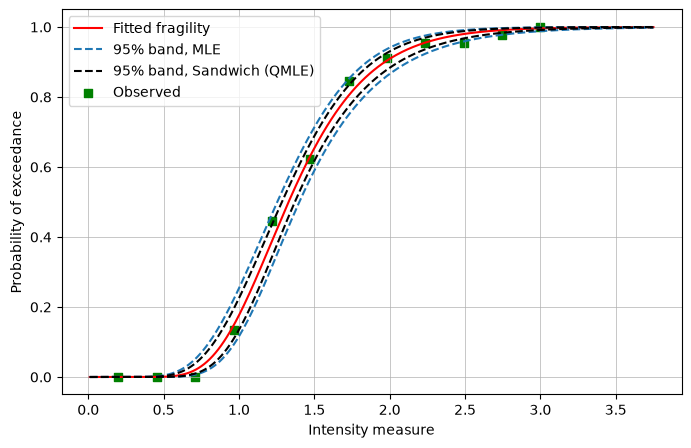

In [3]:
ax = pf.plot_fit(fit, band="both")  # MLE and sandwich bands
ax.figure.set_size_inches(8, 5)

In [4]:
print(fit.misspecification_test())  # White's information-matrix test
print(
    fit.misspecification_test(n_boot=200)
)  # + parametric-bootstrap p-value (better with few stripes)
print(fit.goodness_of_fit())

TestResult(name='White information-matrix test', statistic=6.195483386855928, dof=3, p_value=0.10247733649896687, p_value_bootstrap=None)
TestResult(name='White information-matrix test', statistic=6.195483386855928, dof=3, p_value=0.10247733649896687, p_value_bootstrap=0.417910447761194)
GoodnessOfFit(deviance=5.047906206518277, dof=10, p_value=0.8879549293342963, pearson=4.5508105211195895, pearson_p_value=0.9190982673296618)


### Other links and overdispersion

`link="logit"` or `"cloglog"`; `overdispersion=True` fits a beta-binomial. `compare_models` ranks fits on the
same data by AIC, BIC and TIC (an AIC whose penalty is robust to misspecification).

In [5]:
candidates = {
    "probit": fit,
    "logit": pf.fit_msa(im, collapses, num_gm, link="logit"),
    "cloglog": pf.fit_msa(im, collapses, num_gm, link="cloglog"),
}
pf.compare_models(candidates).round(2)

,loglik,n_params,AIC,BIC,TIC,dAIC,dBIC,dTIC
probit,-15.48,2.0,34.96,35.93,32.58,0.00,0.00,0.21
logit,-15.50,2.0,35.00,35.97,32.37,0.04,0.04,0.00
cloglog,-23.00,2.0,50.00,50.97,52.31,15.05,15.05,19.94


### Collapse risk with parameter uncertainty

In [6]:
hazard = pf.HazardCurve.from_return_periods(
    im, [15, 25, 50, 100, 250, 500, 1000, 2500, 3000, 3500, 3700, 4000]
)
for cov in ("mle", "sandwich"):
    unc = pf.frequency_uncertainty(fit, hazard, cov=cov, im_grid=np.linspace(0.2, 3, 400))
    print(
        f"{cov:9s} MAFC = {unc.mean:.3e}  CoV = {unc.cov:.3f}  90% interval = "
        + ", ".join(f"{v:.2e}" for v in unc.interval(0.9))
    )

mle       MAFC = 4.593e-03  CoV = 0.124  90% interval = 3.71e-03, 5.55e-03
sandwich  MAFC = 4.593e-03  CoV = 0.080  90% interval = 4.01e-03, 5.22e-03


## 2. Field damage data (one 0/1 outcome per building)

Buildings hit by the same earthquake share ground-motion and site effects, so their outcomes are correlated.
Passing `cluster=` makes the sandwich covariance account for it; the plain MLE standard errors are too small.

In [7]:
events = np.repeat(np.arange(25), 30)
sa = rng.lognormal(0, 0.5, events.size)
event_effect = np.repeat(rng.normal(0, 0.8, 25), 30)
damaged = rng.random(sa.size) < pf.links.get_link("logit").cdf(
    -0.5 + 1.5 * np.log(sa) + event_effect
)

field = pf.fit_field_data(sa, damaged, link="logit", cluster=events)
field.summary()

,estimate,se_mle,se_sandwich,ratio
intercept,-0.492196,0.078816,0.18791,2.384162
ln(im),1.279586,0.170453,0.14640,0.858886


## 3. IDA capacities, with censoring

One capacity per record. Records that never reached the limit state (up to the largest intensity analysed) are
right-censored rather than dropped.

In [8]:
capacity = np.exp(np.log(1.5) + 0.45 * rng.standard_normal(60))
limit = 2.5
censored = capacity > limit
ida = pf.fit_ida(np.where(censored, limit, capacity), censored)
print(ida.summary())
lo, hi = ida.profile_interval("theta")  # likelihood-based interval, no symmetry assumed
print(f"theta 95% profile interval: ({lo:.3f}, {hi:.3f})")

       estimate    se_mle  se_sandwich     ratio
theta  1.616251  0.089465     0.089173  0.996738
beta   0.421922  0.042735     0.037616  0.880218
theta 95% profile interval: (1.449, 1.809)


## 4. Cloud analysis

Unscaled records give paired `(im, edp)` values. The threshold only affects the curve, so one fit serves every
limit state. Records that collapsed can be flagged with `collapse=` (modified cloud).

In [9]:
im_c = np.exp(rng.uniform(np.log(0.1), np.log(3), 150))
edp = np.exp(-4 + 1.1 * np.log(im_c) + 0.5 * rng.standard_normal(150))
cloud = pf.fit_cloud(im_c, edp, threshold=0.02)
for thr in (0.01, 0.02, 0.04):
    print(thr, cloud.lognormal_parameters(threshold=thr).theta)

0.01 0.586655915146993
0.02 1.1596452151679795
0.04 2.292275574729425


## 5. Ordered damage states

A cumulative-link model with a shared slope gives non-crossing curves `P(DS >= j | im)`. Damage states can be
converted to losses and integrated with the hazard for an expected annual loss.

In [10]:
x = np.repeat(np.linspace(0.2, 3, 15), 40)
state = np.digitize(1.2 * np.log(x) + rng.standard_normal(x.size), [-1.0, 0.2, 1.2])
ds = pf.fit_damage_states(x, state)
print(ds.summary())
grid = np.linspace(0.1, 4, 400)
losses = [0.0, 0.1, 0.4, 1.0]  # mean loss ratio in DS0..DS3
eal = pf.expected_annual_loss(
    ds,
    pf.HazardCurve.from_return_periods([0.1, 0.5, 1, 2, 4], [10, 100, 500, 2500, 10000]),
    losses,
    grid,
)
print(f"expected annual loss ratio = {eal:.2e}")

        estimate    se_mle  se_sandwich     ratio
alpha1  1.010576  0.074660     0.074008  0.991267
alpha2 -0.300982  0.063329     0.063105  0.996464
alpha3 -1.213232  0.071709     0.073551  1.025696
ln(im)  1.212581  0.074832     0.071624  0.957136
expected annual loss ratio = 2.83e-02


## 6. Small samples: bootstrap and Bayesian

`resample="pairs"` resamples whole stripes (the bootstrap counterpart of the sandwich), `"nonparametric"` resamples
ground motions within stripes and `"parametric"` simulates from the fitted model. Informative priors can be
combined with sparse data.

In [11]:
boot = fit.bootstrap(300, resample="pairs")
print(boot.interval(0.9))

          lower     upper
theta  1.284451  1.378475
beta   0.277752  0.341867


In [12]:
from scipy.stats import lognorm

prior = pf.independent_priors(
    fit.likelihood, theta=lognorm(0.3, scale=1.0), beta=lognorm(0.3, scale=0.4)
)
post = fit.posterior(log_prior=prior, n_samples=3000, burn_in=1500)
post.summary().round(3)

,mean,sd,lower,upper,ess
theta,1.324,0.038,1.253,1.396,375.078
beta,0.316,0.025,0.271,0.365,442.536


## 7. Reporting

`fragility_table` gives median / dispersion with standard errors (`Theta_0`, `Theta_1`, `Family` columns, as in
FEMA P-58 style fragility databases) for any lognormal-form fit.

In [13]:
pf.fragility_table(
    {"MSA": fit, "IDA": ida, "Cloud (0.02)": cloud}, threshold=0.02
) if False else pf.fragility_table({"MSA": fit, "IDA": ida})

,Family,Theta_0,Theta_1,se_Theta_0,se_Theta_1,corr,covariance,n_obs
ID,,,,,,,,
MSA,lognormal,1.328865,0.306130,0.021770,0.017308,-0.402844,sandwich,12
IDA,lognormal,1.616251,0.421922,0.089173,0.037616,0.028229,sandwich,60
